# Dataset Info

The payments table contains 100K entries. For this notebook, 2K entries where selected. In order to not have bias inside data, we specifically selected 33% of the payments as being from the Downtown store, 33% from the Suburban store, and 33% from the Online store.

## Data Selection

The queries that we run are the following:

```
SELECT * FROM store.payments WHERE channel = 'Physical - Downtown' LIMIT 0,666 ORDER BY RANDOM()
UNION
SELECT * FROM store.payments WHERE channel = 'Physical - Suburban' LIMIT 0,667 ORDER BY RANDOM()
UNION
SELECT * FROM store.payments WHERE channel = 'Online' LIMIT 0,667 ORDER BY RANDOM()
```

In [9]:
%pip install mysql-connector-python

  Using cached mysql_connector_python-9.4.0-cp39-cp39-macosx_14_0_arm64.whl (17.5 MB)
You should consider upgrading via the '/Users/gabigutu/05Work/Teach/Link_Academy/2025-2026/Python/26_07-LA-Py-Data_Analysis/code/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from mysql.connector import connect as mysql_connect

In [17]:
# Connect to MySQL

connection = mysql_connect(
    host='127.0.0.1',
    port=3307,
    user='root', # 'root'
    password='', # ''
    database='academy'
)

In [22]:
my_cursor = connection.cursor(dictionary=True)

In [23]:
my_cursor.execute("SELECT * FROM store.payments WHERE channel = 'Physical - Downtown' ORDER BY RAND() LIMIT 0,666")
downtown_payments = my_cursor.fetchall()
downtown_payments

[{'transaction_id': 'TXN-1036468',
  'timestamp': datetime.datetime(2025, 5, 25, 12, 42, 48),
  'customer_id': 'GUEST',
  'channel': 'Physical - Downtown',
  'product_category': 'Electronics',
  'amount': Decimal('88.47'),
  'payment_method': 'Cash',
  'status': 'Completed'},
 {'transaction_id': 'TXN-1048429',
  'timestamp': datetime.datetime(2025, 8, 21, 6, 14, 37),
  'customer_id': 'CUST-16660',
  'channel': 'Physical - Downtown',
  'product_category': 'Electronics',
  'amount': Decimal('161.38'),
  'payment_method': 'Credit Card',
  'status': 'Completed'},
 {'transaction_id': 'TXN-1001860',
  'timestamp': datetime.datetime(2024, 9, 15, 0, 28, 21),
  'customer_id': 'CUST-11286',
  'channel': 'Physical - Downtown',
  'product_category': 'Home & Kitchen',
  'amount': Decimal('54.51'),
  'payment_method': 'Credit Card',
  'status': 'Completed'},
 {'transaction_id': 'TXN-1003488',
  'timestamp': datetime.datetime(2024, 9, 27, 2, 38, 15),
  'customer_id': 'GUEST',
  'channel': 'Physical -

In [25]:
df_downtown = pd.DataFrame(downtown_payments)
df_downtown

,transaction_id,timestamp,customer_id,channel,product_category,amount,payment_method,status
0,TXN-1036468,2025-05-25 12:42:48,GUEST,Physical - Downtown,Electronics,88.47,Cash,Completed
1,TXN-1048429,2025-08-21 06:14:37,CUST-16660,Physical - Downtown,Electronics,161.38,Credit Card,Completed
2,TXN-1001860,2024-09-15 00:28:21,CUST-11286,Physical - Downtown,Home & Kitchen,54.51,Credit Card,Completed
3,TXN-1003488,2024-09-27 02:38:15,GUEST,Physical - Downtown,Electronics,19.02,Debit Card,Completed
4,TXN-1011416,2024-11-23 18:04:50,CUST-18559,Physical - Downtown,Electronics,94.27,Apple Pay,Completed
...,...,...,...,...,...,...,...,...
661,TXN-1075179,2026-03-03 17:19:20,CUST-12140,Physical - Downtown,Beauty & Personal Care,43.39,Cash,Completed
662,TXN-1071809,2026-02-07 17:24:18,CUST-15018,Physical - Downtown,Beauty & Personal Care,14.10,Credit Card,Completed
663,TXN-1043429,2025-07-16 02:16:35,CUST-21279,Physical - Downtown,Clothing,36.61,Debit Card,Completed
664,TXN-1056778,2025-10-20 23:43:39,GUEST,Physical - Downtown,Home & Kitchen,87.04,Credit Card,Completed


In [26]:
my_cursor.execute("SELECT * FROM store.payments WHERE channel = 'Physical - Suburban' ORDER BY RAND() LIMIT 0,667")
df_suburban = pd.DataFrame(my_cursor.fetchall())
df_suburban

,transaction_id,timestamp,customer_id,channel,product_category,amount,payment_method,status
0,TXN-1034080,2025-05-08 17:57:10,GUEST,Physical - Suburban,Beauty & Personal Care,34.61,Debit Card,Completed
1,TXN-1014516,2024-12-16 13:56:31,CUST-23786,Physical - Suburban,Home & Kitchen,59.21,Credit Card,Completed
2,TXN-1044449,2025-07-23 18:19:19,GUEST,Physical - Suburban,Home & Kitchen,60.33,Credit Card,Completed
3,TXN-1050532,2025-09-05 15:26:49,CUST-21692,Physical - Suburban,Home & Kitchen,129.75,Credit Card,Completed
4,TXN-1041246,2025-06-29 23:36:54,CUST-12543,Physical - Suburban,Electronics,178.27,Credit Card,Completed
...,...,...,...,...,...,...,...,...
662,TXN-1061537,2025-11-24 22:18:49,CUST-11314,Physical - Suburban,Home & Kitchen,54.05,Credit Card,Completed
663,TXN-1029404,2025-04-04 15:36:44,CUST-14636,Physical - Suburban,Home & Kitchen,163.25,Debit Card,Completed
664,TXN-1045460,2025-07-30 19:28:46,GUEST,Physical - Suburban,Home & Kitchen,43.23,Cash,Completed
665,TXN-1055848,2025-10-14 00:23:26,CUST-10715,Physical - Suburban,Books & Stationery,15.92,Apple Pay,Refunded


In [27]:
my_cursor.execute("SELECT * FROM store.payments WHERE channel = 'Online' ORDER BY RAND() LIMIT 0,667")
df_online = pd.DataFrame(my_cursor.fetchall())
df_online

,transaction_id,timestamp,customer_id,channel,product_category,amount,payment_method,status
0,TXN-1022587,2025-02-12 14:44:33,CUST-11265,Online,Clothing,47.41,PayPal,Completed
1,TXN-1075943,2026-03-09 14:21:24,CUST-22275,Online,Books & Stationery,31.22,Credit Card,Completed
2,TXN-1008872,2024-11-04 16:28:22,CUST-12107,Online,Clothing,31.83,Credit Card,Completed
3,TXN-1024112,2025-02-24 00:24:13,CUST-24626,Online,Home & Kitchen,52.48,Apple Pay,Completed
4,TXN-1020947,2025-02-01 05:40:19,GUEST,Online,Books & Stationery,25.25,Debit Card,Completed
...,...,...,...,...,...,...,...,...
662,TXN-1078542,2026-03-28 20:25:56,CUST-22989,Online,Clothing,48.03,PayPal,Completed
663,TXN-1045381,2025-07-30 05:11:21,CUST-18295,Online,Home & Kitchen,93.70,Apple Pay,Completed
664,TXN-1068532,2026-01-15 07:07:47,GUEST,Online,Electronics,151.10,Credit Card,Completed
665,TXN-1012980,2024-12-05 06:56:05,CUST-13491,Online,Clothing,31.02,Apple Pay,Completed


In [29]:
df_2k = pd.concat([df_downtown, df_suburban, df_online], ignore_index=True)
df_2k

,transaction_id,timestamp,customer_id,channel,product_category,amount,payment_method,status
0,TXN-1036468,2025-05-25 12:42:48,GUEST,Physical - Downtown,Electronics,88.47,Cash,Completed
1,TXN-1048429,2025-08-21 06:14:37,CUST-16660,Physical - Downtown,Electronics,161.38,Credit Card,Completed
2,TXN-1001860,2024-09-15 00:28:21,CUST-11286,Physical - Downtown,Home & Kitchen,54.51,Credit Card,Completed
3,TXN-1003488,2024-09-27 02:38:15,GUEST,Physical - Downtown,Electronics,19.02,Debit Card,Completed
4,TXN-1011416,2024-11-23 18:04:50,CUST-18559,Physical - Downtown,Electronics,94.27,Apple Pay,Completed
...,...,...,...,...,...,...,...,...
1995,TXN-1078542,2026-03-28 20:25:56,CUST-22989,Online,Clothing,48.03,PayPal,Completed
1996,TXN-1045381,2025-07-30 05:11:21,CUST-18295,Online,Home & Kitchen,93.70,Apple Pay,Completed
1997,TXN-1068532,2026-01-15 07:07:47,GUEST,Online,Electronics,151.10,Credit Card,Completed
1998,TXN-1012980,2024-12-05 06:56:05,CUST-13491,Online,Clothing,31.02,Apple Pay,Completed


In [33]:
df_2k['amount'].max()

Decimal('1068.03')

(array([1895.,   84.,   14.,    3.,    4.]),
 array([   7.06 ,  219.254,  431.448,  643.642,  855.836, 1068.03 ]),
 <BarContainer object of 5 artists>)

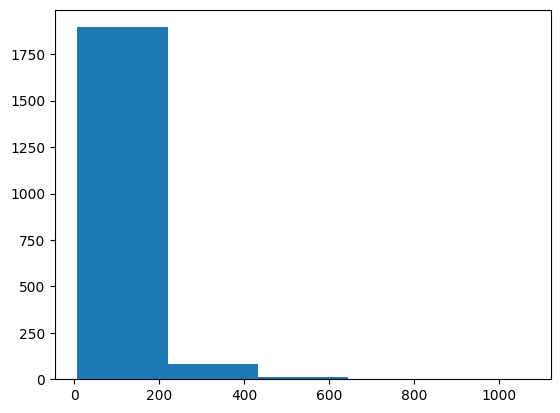

In [32]:
plt.hist(list(df_2k['amount']), bins=5)

In [36]:
df_2k_cheap = df_2k [ df_2k['amount'].between(0, 213.6) ] 
df_2k_cheap

,transaction_id,timestamp,customer_id,channel,product_category,amount,payment_method,status
0,TXN-1036468,2025-05-25 12:42:48,GUEST,Physical - Downtown,Electronics,88.47,Cash,Completed
1,TXN-1048429,2025-08-21 06:14:37,CUST-16660,Physical - Downtown,Electronics,161.38,Credit Card,Completed
2,TXN-1001860,2024-09-15 00:28:21,CUST-11286,Physical - Downtown,Home & Kitchen,54.51,Credit Card,Completed
3,TXN-1003488,2024-09-27 02:38:15,GUEST,Physical - Downtown,Electronics,19.02,Debit Card,Completed
4,TXN-1011416,2024-11-23 18:04:50,CUST-18559,Physical - Downtown,Electronics,94.27,Apple Pay,Completed
...,...,...,...,...,...,...,...,...
1995,TXN-1078542,2026-03-28 20:25:56,CUST-22989,Online,Clothing,48.03,PayPal,Completed
1996,TXN-1045381,2025-07-30 05:11:21,CUST-18295,Online,Home & Kitchen,93.70,Apple Pay,Completed
1997,TXN-1068532,2026-01-15 07:07:47,GUEST,Online,Electronics,151.10,Credit Card,Completed
1998,TXN-1012980,2024-12-05 06:56:05,CUST-13491,Online,Clothing,31.02,Apple Pay,Completed


(array([212., 371., 325., 277., 161., 112., 112.,  86.,  62.,  50.,  38.,
         31.,  21.,  22.,  10.]),
 array([  7.06      ,  20.77333333,  34.48666667,  48.2       ,
         61.91333333,  75.62666667,  89.34      , 103.05333333,
        116.76666667, 130.48      , 144.19333333, 157.90666667,
        171.62      , 185.33333333, 199.04666667, 212.76      ]),
 <BarContainer object of 15 artists>)

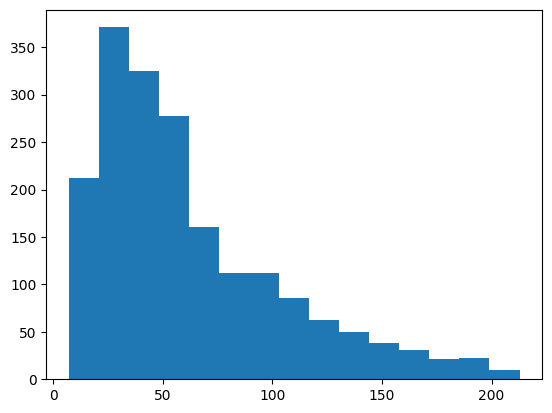

In [40]:
plt.hist(list(df_2k_cheap['amount']), bins=15)

In [7]:
df = pd.read_csv('data/payments_2k.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'data/payments_2k.csv'

In [ ]:
df